In [21]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.visualization import plot_histogram
from numpy import pi, cos, sin, linspace
import matplotlib.pyplot as plt
import numpy as np
from math import gcd, floor, log
from fractions import Fraction
import random

Make the Hadamarg gate with the state $\ket{\psi_\theta}=\cos\theta\ket{0}+\sin\theta\ket{1}$

In [22]:
# make the state |psi_theta>=cos(theta)|0>+sin(theta)|1>
psi1 = Statevector([cos(pi/8), sin(pi/8)])
psi2 = Statevector([cos(5*pi/8), sin(5*pi/8)])

# to create the operator we just apply the Operator function. It makes the outer product
H = Operator(psi1) - Operator(psi2) # hadamard gate
display(H.draw('latex'))

<IPython.core.display.Latex object>

We implement the phase kick-back phenomenon with low precision

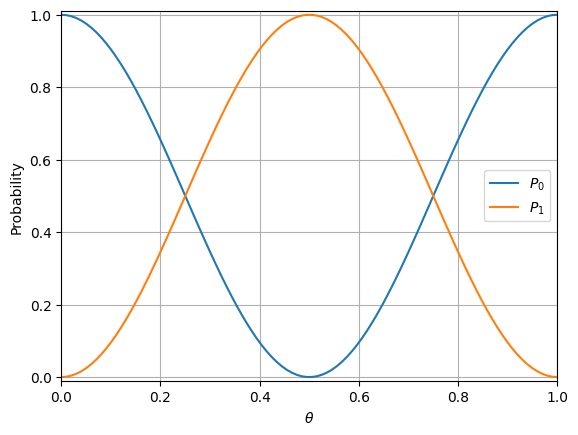

In [23]:
# make the graph of theta and the probability
values = linspace(0,1,100)
p0 = [cos(pi*theta)**2 for theta in values]
p1 = [sin(pi*theta)**2 for theta in values]

fig, ax = plt.subplots()

ax.plot(values, p0, lw=1.5, label='$P_0$')
ax.plot(values, p1, lw=1.5, label='$P_1$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()
fig.savefig('../figs/phase-estimation-and-factoring-P-1cU.png', dpi=77, bbox_inches='tight')

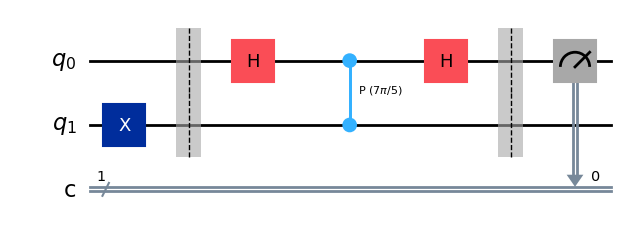

In [24]:
theta = 0.7 # any value [0,1)

# create the quantum circuit
qc = QuantumCircuit(2, 1)

# prepare the eigenvector in |1>
qc.x(1)
qc.barrier()

# implement the procedure
qc.h(0)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.h(0)
qc.barrier()

# measurement
qc.measure(qubit=0, cbit=0)

# draw circuit
display(qc.draw(output='mpl'))

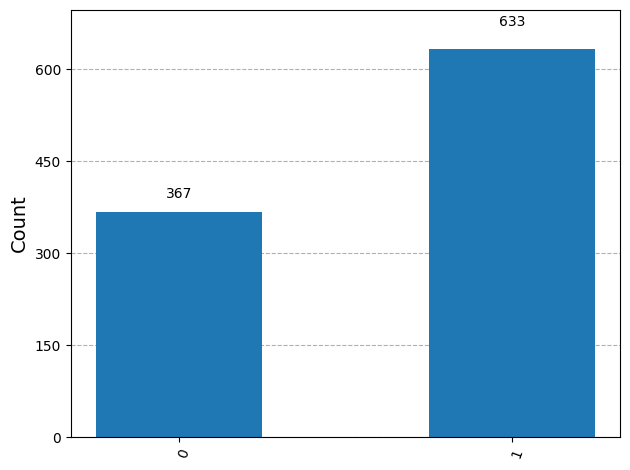

P0=cos(pi * 0.7)**2 = 0.3455
P1=sin(pi * 0.7)**2 = 0.6545


In [25]:
# simulate the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

# probabilities
print(f"P0=cos(pi * {theta})**2 = {cos(pi * theta) ** 2:.4f}")
print(f"P1=sin(pi * {theta})**2 = {sin(pi * theta) ** 2:.4f}")

If we double the pase, that is, add other controlled-U gate. With this, we increase the information of $\theta$, because now we know more values to obtain the desire result

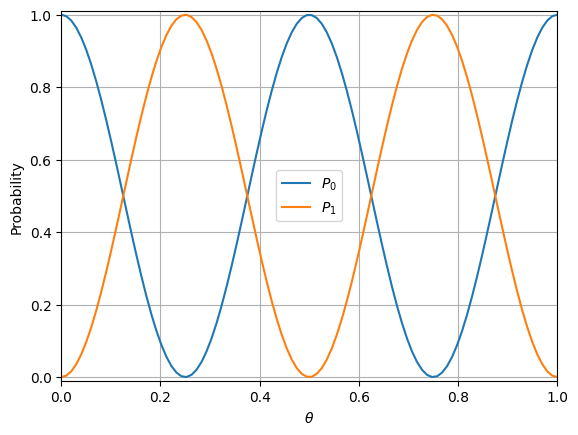

In [26]:
# make the graph of theta and the probability
values = linspace(0,1,100)
p0 = [cos(2*pi*theta)**2 for theta in values]
p1 = [sin(2*pi*theta)**2 for theta in values]

fig, ax = plt.subplots()

ax.plot(values, p0, lw=1.5, label='$P_0$')
ax.plot(values, p1, lw=1.5, label='$P_1$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()
fig.savefig('../figs/phase-estimation-and-factoring-P-2cU.png', dpi=77, bbox_inches='tight')

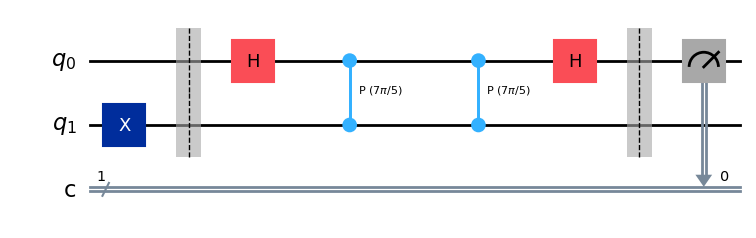

In [27]:
theta = 0.7 # any value [0,1)

# create the quantum circuit
qc = QuantumCircuit(2, 1)

# prepare the eigenvector in |1>
qc.x(1)
qc.barrier()

# implement the procedure
qc.h(0)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.h(0)
qc.barrier()

# measurement
qc.measure(qubit=0, cbit=0)

# draw circuit
display(qc.draw(output='mpl'))

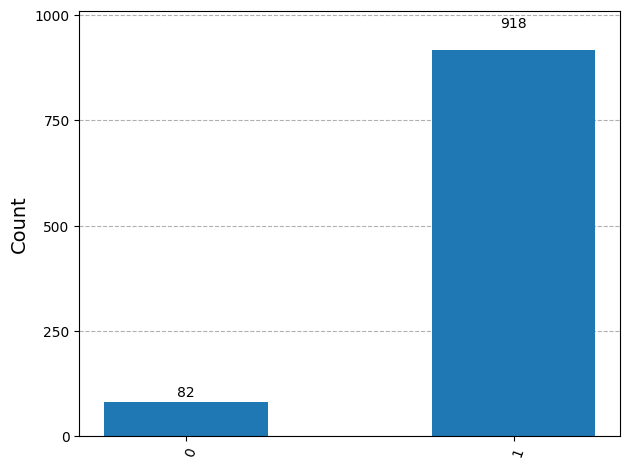

P0=cos(2*pi * 0.7)**2 = 0.0955
P1=sin(2*pi * 0.7)**2 = 0.9045


In [28]:
# simulate the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

# probabilities
print(f"P0=cos(2*pi * {theta})**2 = {cos(2*pi * theta) ** 2:.4f}")
print(f"P1=sin(2*pi * {theta})**2 = {sin(2*pi * theta) ** 2:.4f}")

We can add more control qubits and combine techniques

C:\Users\isaac\AppData\Local\Temp\ipykernel_9896\2405416612.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return 1/16 * (sin(2**m * pi* (theta - y/2**m))**2)/(sin(pi* (theta - y/2**m))**2)


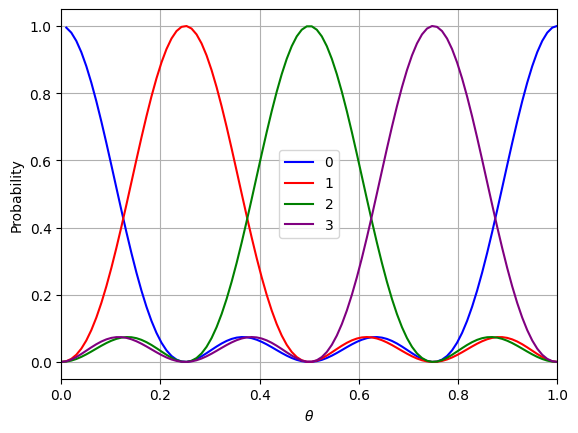

In [29]:
# function of Py
def py(theta, m, y):
    return 1/16 * (sin(2**m * pi* (theta - y/2**m))**2)/(sin(pi* (theta - y/2**m))**2)

# values of the probability
values = linspace(0,1,100)
p0 = [py(theta, 2, 0) for theta in values]
p1 = [py(theta, 2, 1) for theta in values]
p2 = [py(theta, 2, 2) for theta in values]
p3 = [py(theta, 2, 3) for theta in values]



# plot
fig, ax = plt.subplots()

ax.plot(values, p0, lw=1.5, color='blue', label='$0$')
ax.plot(values, p1, lw=1.5, color='red', label='$1$')
ax.plot(values, p2, lw=1.5, color='green', label='$2$')
ax.plot(values, p3, lw=1.5, color='purple', label='$3$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
#ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()
fig.savefig('../figs/phase-estimation-and-factoring-P-3cU-more-qubits.png', dpi=77, bbox_inches='tight')

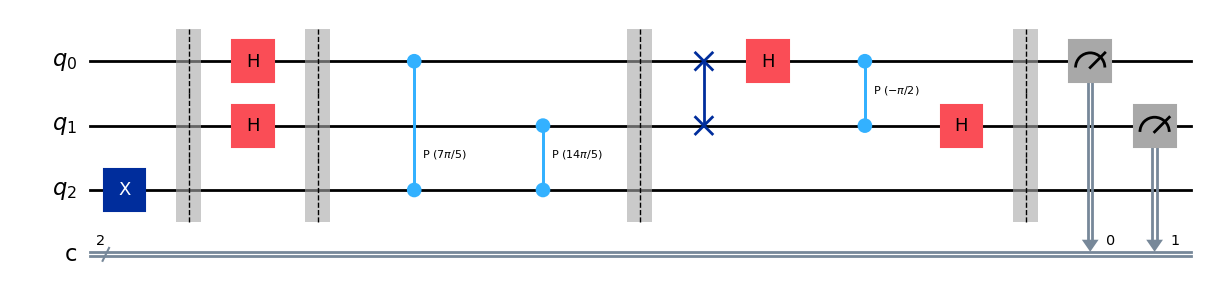

In [30]:
theta = 0.7

# create quantum circuit
qc = QuantumCircuit(3, 2)

# prepare the eigenvetor
qc.x(2)
qc.barrier()

# initial Hadamard gates
qc.h(0)
qc.h(1)
qc.barrier()

# controlled-U gates
qc.cp(2*pi*theta, control_qubit=0, target_qubit=2)
qc.cp(2*pi*(2*theta), control_qubit=1, target_qubit=2)
qc.barrier()

# implementation of the inverse of the two qubit QFT gate
qc.swap(qubit1=0, qubit2=1)
qc.h(0)
qc.cp(-pi/2, control_qubit=0, target_qubit=1)
qc.h(1)
qc.barrier()

# measurements
qc.measure(qubit=[0, 1], cbit=[0, 1])

# draw
display(qc.draw(output='mpl'))

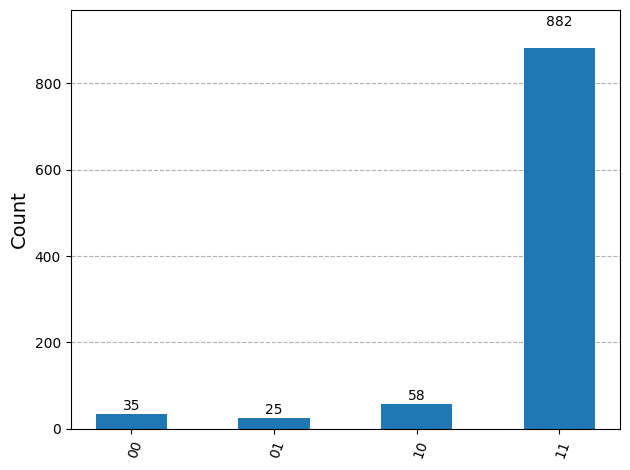

In [31]:
# run the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()

# plot
display(plot_histogram(statistics))

We can implement the QFT using qiskit. This to avoid writting many gates

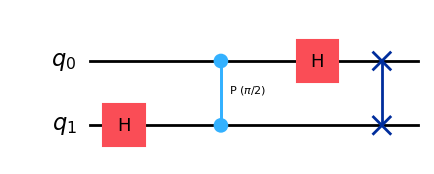

In [32]:
# for N=2 it's what we had
display(QFT(num_qubits=2).decompose().draw(output='mpl'))

We know that increasing the conytrol qubits and the c-U gates, imporves the probability of finding $\theta$. Or in better words, we have more information to determine $\theta$

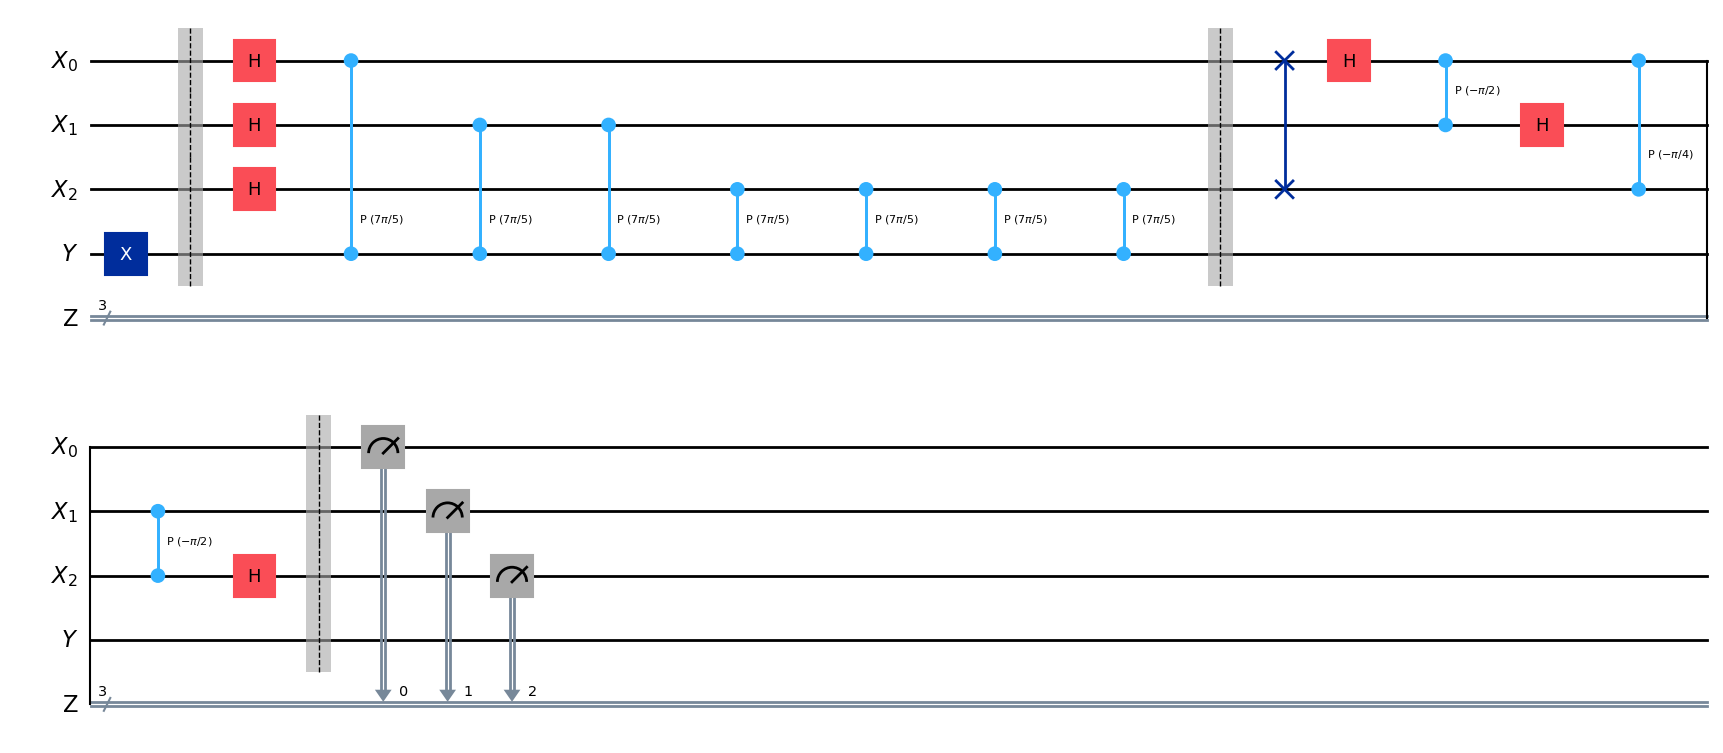

In [33]:
theta = 0.7
m = 3  # Number of control qubits

control = QuantumRegister(m, name="X")
target = QuantumRegister(1, name="Y")
output = ClassicalRegister(m, name="Z")
qc = QuantumCircuit(control, target, output)

# Prepare the eigenvector
qc.x(target)
qc.barrier()

# Perform phase estimation
for index, qubit in enumerate(control):
    qc.h(qubit)
    for _ in range(2**index):
        qc.cp(2 * pi * theta, qubit, target)
qc.barrier()

# Perform the inverse quantum Fourier transform
qc.compose(
    QFT(m, inverse=True).decompose(),
    inplace=True
)
qc.barrier()

# Measure everything
qc.measure(range(m), range(m))

display(qc.draw(output="mpl"))

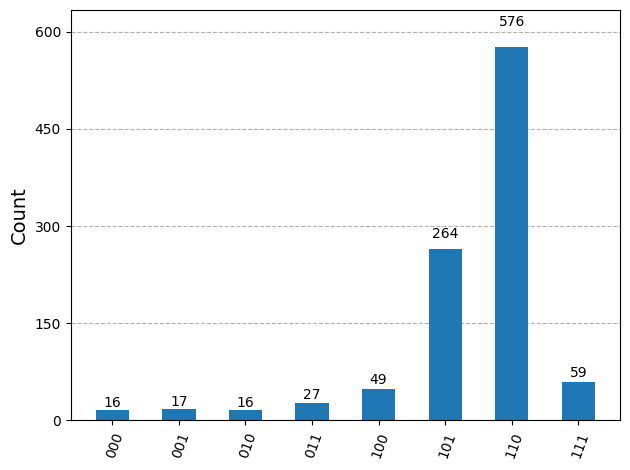

In [34]:
result = AerSimulator().run(qc).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

In [35]:
most_probable = int(max(statistics, key=statistics.get),2)

print(f"Most probable output: {most_probable}")
print(f"Estimated theta: {most_probable/2**m}")

Most probable output: 6
Estimated theta: 0.75


## Shor's algorithm

In [36]:
# definition of the Mb gate for b in Zn*
def mod_mult_gate(b,N):
    if gcd(b,N)>1:
        print(f"Error: gcd({b},{N}) > 1")
    else:
        n = floor(log(N-1,2)) + 1
        U = np.full((2**n,2**n),0)
        for x in range(N): U[b*x % N][x] = 1
        for x in range(N,2**n): U[x][x] = 1
        G = UnitaryGate(U)
        G.name = f"M_{b}"
        return G
    
# funtion to build a quantum circuit associated with order-finding
def order_finding_circuit(a,N):
    if gcd(a,N)>1:
        print(f"Error: gcd({a},{N}) > 1")
    else:
        n = floor(log(N-1,2)) + 1
        m = 2*n

        control = QuantumRegister(m, name = "X")
        target = QuantumRegister(n, name = "Y")
        output = ClassicalRegister(m, name = "Z")
        circuit = QuantumCircuit(control, target, output)

        # Initialize the target register to the state |1>
        circuit.x(m)

        # Add the Hadamard gates and controlled versions of the
        # multiplication gates
        for k, qubit in enumerate(control):
            circuit.h(k)
            b = pow(a,2**k,N)
            circuit.compose(
                mod_mult_gate(b,N).control(),
                qubits = [qubit] + list(target),
                inplace=True)

        # Apply the inverse QFT to the control register
        circuit.compose(
            QFT(m, inverse=True),
            qubits=control,
            inplace=True)

        # Measure the control register
        circuit.measure(control, output)

        return circuit
    
# function of the order-finding circuit
def find_order(a,N):
    if gcd(a,N)>1:
        print(f"Error: gcd({a},{N}) > 1")
    else:
        n = floor(log(N-1,2)) + 1
        m = 2*n
        circuit = order_finding_circuit(a,N)
        transpiled_circuit = transpile(circuit,AerSimulator())

        while True:
            result = AerSimulator().run(
                transpiled_circuit,
                shots=1,
                memory=True).result()
            y = int(result.get_memory()[0],2)
            r = Fraction(y/2**m).limit_denominator(N).denominator
            if pow(a,r,N)==1: break
        return r

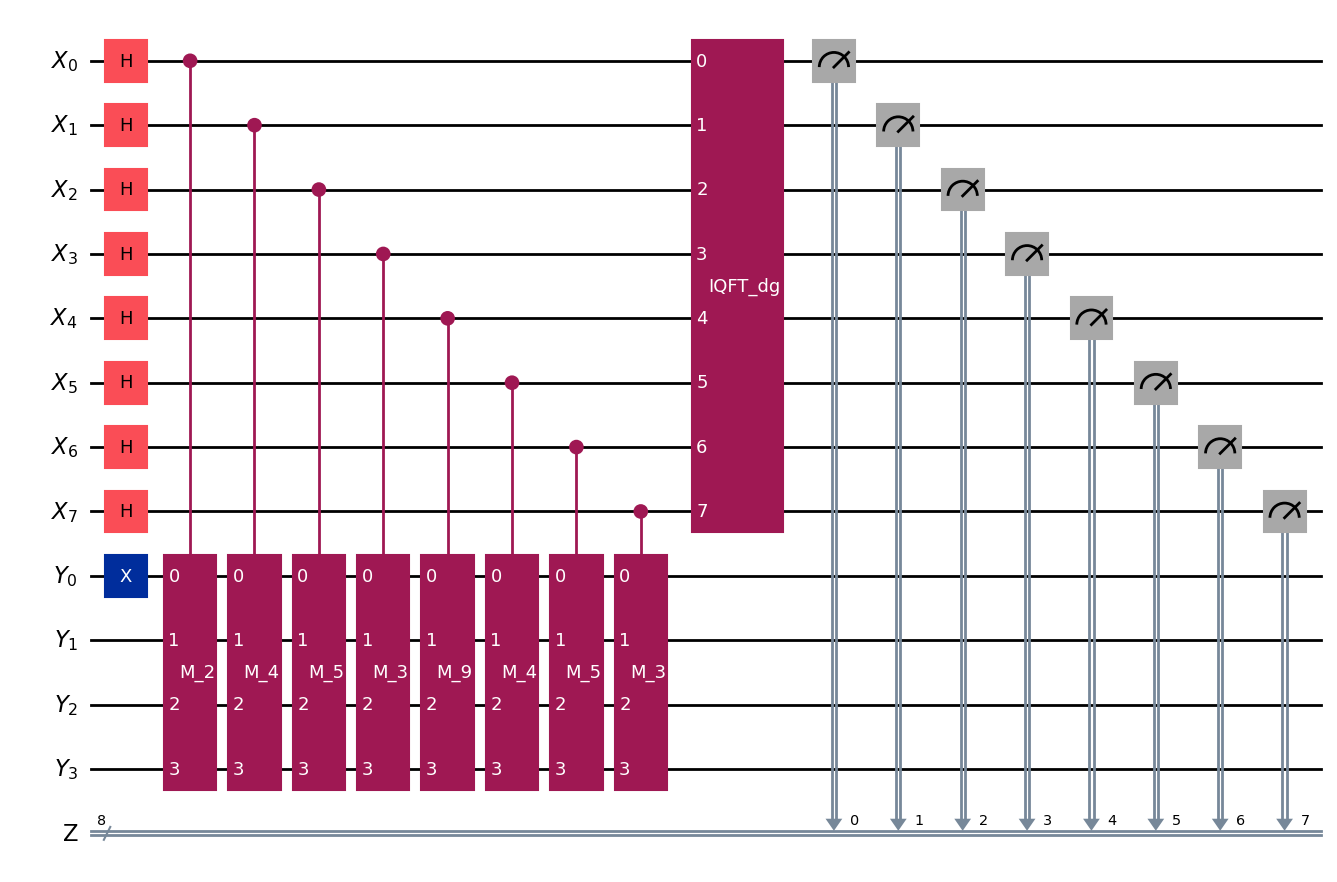

In [37]:
order_finding_circuit(2,11).draw(output = "mpl")

In [38]:
N = 11
a = 2
print(f"The order of {a} modulo {N} is {find_order(a,N)}.")

The order of 2 modulo 11 is 10.


In [39]:
# find non trivial solutions for N
N = 39

FACTOR_FOUND = False

# First we'll check to see if N is even or a nontrivial power.
# Order finding won't help for factoring a *prime* power, but
# we can easily find a nontrivial factor of *any* nontrivial
# power, whether prime or not.

if N % 2 == 0:
    print("Even number")
    d = 2
    FACTOR_FOUND = True
else:
    for k in range(2,round(log(N,2))+1):
        d = int(round(N ** (1/k)))
        if d**k == N:
            FACTOR_FOUND = True
            print("Number is a power")
            break

# Now we'll iterate until a nontrivial factor of N is found.

while not FACTOR_FOUND:
    a = random.randint(2,N-1)
    d = gcd(a,N)
    if d>1:
        FACTOR_FOUND = True
        print(f"Lucky guess of {a} modulo {N}")
    else:
        r = find_order(a,N)
        print(f"The order of {a} modulo {N} is {r}")
        if r % 2 == 0:
            x = pow(a,r//2,N) - 1
            d = gcd(x,N)
            if d>1: FACTOR_FOUND = True

print(f"Factor found: {d}")

The order of 10 modulo 39 is 6
Factor found: 3
